# Рекомендательные системы по фильмам

#### Проект выполнил студент Мухитова Азалия, группа 22П-2

Цели и задачи проекта:

Разработайте программный интерфейс для итоговой модели машинного 
обучения. API должен позволить приложению пользователя получать:  
1) списка топ-10 популярных фильмов (на основе взвешенных 
рейтингов); 
2) доступ к рекомендательной системе для прогнозирования списка 10 
рекомендованных фильмов по жанру; 
3) доступ к рекомендательной системе для прогнозирования списка 10 
рекомендованных фильмов по контенту (по названию фильма); 
4) доступ к рекомендательной системе для прогнозирования списка 10 
рекомендованных фильмов по контенту (коллаборативная 
фильтрация)

___

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
%matplotlib inline

In [37]:
movies=pd.read_csv("movies_metadata.csv")
credits=pd.read_csv("credits.csv")
keywords=pd.read_csv("keywords.csv")
ratings_small=pd.read_csv("ratings_small.csv")

C:\Users\ROG\AppData\Local\Temp\ipykernel_9588\4186191040.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv("movies_metadata.csv")


In [38]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [39]:
# Проверим размер датасета и типы данных
print(movies.shape)
print(movies.info())

(45466, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  obj

В главном датасете 24 столбца и 45.466 записей.

In [ ]:
# Удалим строки с критически важными пропусками (столбцы с названием фильма, кол-вом отзывов и средним рейтингом)
movies = movies.dropna(subset=['vote_average', 'vote_count', 'title'])

In [41]:
# Проверим размер датасета и типы данных
print(movies.shape)
print(movies.info())

(45460, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 45460 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45460 non-null  object 
 1   belongs_to_collection  4490 non-null   object 
 2   budget                 45460 non-null  object 
 3   genres                 45460 non-null  object 
 4   homepage               7778 non-null   object 
 5   id                     45460 non-null  object 
 6   imdb_id                45443 non-null  object 
 7   original_language      45449 non-null  object 
 8   original_title         45460 non-null  object 
 9   overview               44506 non-null  object 
 10  popularity             45460 non-null  object 
 11  poster_path            45077 non-null  object 
 12  production_companies   45460 non-null  object 
 13  production_countries   45460 non-null  object 
 14  release_date           45376 non-null  object 


In [ ]:
# Преобразуем vote_count и vote_average в числовой формат
movies['vote_count'] = pd.to_numeric(movies['vote_count'], errors='coerce')
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce')

In [43]:
# Удалим строки, где преобразование не удалось (получили NaN)
movies = movies.dropna(subset=['vote_count', 'vote_average'])

In [ ]:
# Преобразуем столбец 'genres' в список жанров
def parse_genres(genres_str):
    try:
        genres_list = ast.literal_eval(genres_str)
        if isinstance(genres_list, list):
            return '|'.join([genre['name'] for genre in genres_list])
        else:
            return ''
    except (ValueError, SyntaxError):
        return ''

In [ ]:
# Применяем функцию к столбцу с жанрами
movies['genres'] = movies['genres'].apply(parse_genres)

In [46]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,Animation|Comedy|Family,http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,Adventure|Fantasy|Family,NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,Romance|Comedy,NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,Comedy|Drama|Romance,NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,Comedy,NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
# Вычисляем взвешенный рейтинг по формуле
# C = средний рейтинг по всем фильмам
C = movies['vote_average'].mean()
# m = минимальное количество голосов для попадания в топ (90-й перцентиль)
m = movies['vote_count'].quantile(0.90)

print(f"Средний рейтинг по всем фильмам (C): {C:.2f}")
print(f"Минимальное количество голосов (m): {m:.0f}")

Средний рейтинг по всем фильмам (C): 5.62
Минимальное количество голосов (m): 160


In [48]:
def weighted_rating(df, m=m, C=C):
    v = df['vote_count']
    R = df['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

In [ ]:
# Применяем функцию для расчета и создаем новый столбец
movies['weighted_rating'] = movies.apply(weighted_rating, axis=1)

In [50]:
top_10_movies = movies[['title', 'weighted_rating', 'vote_count', 'vote_average']].sort_values('weighted_rating', ascending=False).head(10)
print("Топ-10 фильмов по взвешенному рейтингу:")
print(top_10_movies)

Топ-10 фильмов по взвешенному рейтингу:
                             title  weighted_rating  vote_count  vote_average
314       The Shawshank Redemption         8.445869      8358.0           8.5
834                  The Godfather         8.425439      6024.0           8.5
10309  Dilwale Dulhania Le Jayenge         8.421453       661.0           9.1
12481              The Dark Knight         8.265477     12269.0           8.3
2843                    Fight Club         8.256385      9678.0           8.3
292                   Pulp Fiction         8.251406      8670.0           8.3
522               Schindler's List         8.206639      4436.0           8.3
23673                     Whiplash         8.205404      4376.0           8.3
5481                 Spirited Away         8.196055      3968.0           8.3
2211             Life Is Beautiful         8.187171      3643.0           8.3


___

## Обогащение данных (Объединяем с credits и keywords)

In [51]:
# Функции для извлечения информации из JSON
def get_director(crew_str):
    """
    Извлекает имя режиссера из строки crew.
    """
    try:
        crew_list = ast.literal_eval(crew_str)
        for person in crew_list:
            if person['job'] == 'Director':
                return person['name']
        return ''
    except (ValueError, SyntaxError):
        return ''

def get_first_three_actors(cast_str):
    """
    Извлекает имена первых трех актеров из строки cast.
    """
    try:
        cast_list = ast.literal_eval(cast_str)
        if isinstance(cast_list, list):
            actors = [actor['name'] for actor in cast_list[:3]] # Берем первых 3-х актеров
            return '|'.join(actors)
        else:
            return ''
    except (ValueError, SyntaxError):
        return ''

def get_keywords(keywords_str):
    """
    Извлекает ключевые слова из строки keywords.
    """
    try:
        keywords_list = ast.literal_eval(keywords_str)
        if isinstance(keywords_list, list):
            keywords = [kw['name'] for kw in keywords_list]
            return '|'.join(keywords)
        else:
            return ''
    except (ValueError, SyntaxError):
        return ''

In [52]:
# Применяем функции к датасетам credits и keywords
credits['director'] = credits['crew'].apply(get_director)
credits['actors'] = credits['cast'].apply(get_first_three_actors)
keywords['parsed_keywords'] = keywords['keywords'].apply(get_keywords)

In [53]:
# Проверим текущие типы данных столбца 'id' в обоих датафреймах
print("Тип id в movies:", movies['id'].dtype)
print("Тип id в credits:", credits['id'].dtype)
print("Тип id в keywords:", keywords['id'].dtype)

Тип id в movies: object
Тип id в credits: int64
Тип id в keywords: int64


In [ ]:
# Функция для преобразования к int
def safe_convert_to_int(df, column_name):
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    df = df.dropna(subset=[column_name])
    df[column_name] = df[column_name].astype('int64')
    return df

# Преобразуем id во всех датафреймах
movies = safe_convert_to_int(movies, 'id')
credits = safe_convert_to_int(credits, 'id')
keywords = safe_convert_to_int(keywords, 'id')

In [55]:
# Теперь объединим все с основным датасетом movies
# Сначала объединим credits (по id)
movies = movies.merge(credits[['id', 'director', 'actors']], on='id', how='left')

In [56]:
# Затем объединим keywords (по id)
movies = movies.merge(keywords[['id', 'parsed_keywords']], on='id', how='left')

In [57]:
# Заполним пропуски пустыми строками
movies['director'] = movies['director'].fillna('')
movies['actors'] = movies['actors'].fillna('')
movies['parsed_keywords'] = movies['parsed_keywords'].fillna('')
movies['overview'] = movies['overview'].fillna('')

In [ ]:
# Создадим "кучу" из данных для контентной рекомендации
movies['metadata_soup'] = (
    movies['overview'] + ' ' + 
    movies['director'] + ' ' + 
    movies['actors'] + ' ' + 
    movies['parsed_keywords'] + ' ' + 
    movies['genres']
)

In [59]:
movies.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'weighted_rating', 'director', 'actors',
       'parsed_keywords', 'metadata_soup'],
      dtype='object')

In [60]:
# Столбцы, не несущие полезной информации для рекомендаций
columns_to_drop = [
    'adult',                  # Почти все фильмы не adult
    'belongs_to_collection',  # Не нужно
    'budget',                 # Не влияет на рекомендации
    'homepage',               # URL-ссылки не нужны
    'imdb_id',                # ID из другой системы
    'original_language',      # Дублируется с spoken_languages
    'original_title',         # Дублируется с title
    'production_companies',   # Не нужно
    'production_countries',   # Не нужно
    'revenue',                # Не влияет на рекомендации
    'spoken_languages',       # Не нужно
    'status',                 # Почти все фильмы имеют статус "Released"
    'tagline',                # Дублируется с overview
    'video',                  # Почти все фильмы не video
    'poster_path',            # URL для постеров
]

In [61]:
# Удаляем ненужные столбцы
movies = movies.drop(columns=columns_to_drop, errors='ignore')

In [62]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46625 entries, 0 to 46624
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genres           46625 non-null  object 
 1   id               46625 non-null  int64  
 2   overview         46625 non-null  object 
 3   popularity       46625 non-null  object 
 4   release_date     46541 non-null  object 
 5   runtime          46361 non-null  float64
 6   title            46625 non-null  object 
 7   vote_average     46625 non-null  float64
 8   vote_count       46625 non-null  float64
 9   weighted_rating  46625 non-null  float64
 10  director         46625 non-null  object 
 11  actors           46625 non-null  object 
 12  parsed_keywords  46625 non-null  object 
 13  metadata_soup    46625 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 5.0+ MB


| Название столбца | Описание |
|------------------|----------|
| **genres** | Жанры фильма|
| **id** |Идентификатор фильма|
| **overview** | Описание |
| **popularity** | Показатель популярности фильма |
| **release_date** | Дата выхода фильма в прокат |
| **runtime** | Продолжительность фильма в минутах |
| **title** | Название фильма |
| **vote_average** | Средняя оценка зрителей |
| **vote_count** | Количество проголосовавших зрителей |
| **weighted_rating** | Взвешенный рейтинг, учитывающий среднюю оценку и количество голосов |
| **director** | Имя режиссера фильма |
| **actors** | Список основных актеров |
| **parsed_keywords** | Ключевые слова или теги, связанные с фильмом |
| **metadata_soup** | Объединенные метаданные для использования в алгоритмах рекомендаций |

___

### Подготовка данных для коллаборативной фильтрации

In [63]:
# Преобразуем id в links_small к тому же типу
links_small = pd.read_csv('links_small.csv')
links_small = safe_convert_to_int(links_small, 'tmdbId')

C:\Users\ROG\AppData\Local\Temp\ipykernel_9588\2928285554.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].astype('int64')


In [ ]:
# Объединим ratings_small с links_small по movieId
ratings_merged = ratings_small.merge(links_small[['movieId', 'tmdbId']], on='movieId', how='inner')

In [ ]:
# Теперь объединим с movies_metadata по tmdbId и id
ratings_merged = ratings_merged.rename(columns={'tmdbId': 'id'})
ratings_final = ratings_merged.merge(movies[['id', 'title']], on='id', how='inner')
ratings_final = ratings_final[['userId', 'id', 'rating', 'title']]
ratings_final = ratings_final.rename(columns={'id': 'movie_id'})

In [68]:
print("Размер итогового датафрейма:", ratings_final.shape)
print(ratings_final.head())

Размер итогового датафрейма: (100122, 4)
   userId  movie_id  rating                 title
0       1      9909     2.5       Dangerous Minds
1       1     11360     3.0                 Dumbo
2       1       819     3.0              Sleepers
3       1      1103     2.0  Escape from New York
4       1     11216     4.0       Cinema Paradiso


In [69]:
movies.head()

,genres,id,overview,popularity,release_date,runtime,title,vote_average,vote_count,weighted_rating,director,actors,parsed_keywords,metadata_soup
0,Animation|Comedy|Family,862,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,81.0,Toy Story,7.7,5415.0,7.640253,John Lasseter,Tom Hanks|Tim Allen|Don Rickles,jealousy|toy|boy|friendship|friends|rivalry|bo...,"Led by Woody, Andy's toys live happily in his ..."
1,Adventure|Fantasy|Family,8844,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,104.0,Jumanji,6.9,2413.0,6.820293,Joe Johnston,Robin Williams|Jonathan Hyde|Kirsten Dunst,board game|disappearance|based on children's b...,When siblings Judy and Peter discover an encha...
2,Romance|Comedy,15602,A family wedding reignites the ancient feud be...,11.7129,1995-12-22,101.0,Grumpier Old Men,6.5,92.0,5.940132,Howard Deutch,Walter Matthau|Jack Lemmon|Ann-Margret,fishing|best friend|duringcreditsstinger|old men,A family wedding reignites the ancient feud be...
3,Comedy|Drama|Romance,31357,"Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,127.0,Waiting to Exhale,6.1,34.0,5.702645,Forest Whitaker,Whitney Houston|Angela Bassett|Loretta Devine,based on novel|interracial relationship|single...,"Cheated on, mistreated and stepped on, the wom..."
4,Comedy,11862,Just when George Banks has recovered from his ...,8.387519,1995-02-10,106.0,Father of the Bride Part II,5.7,173.0,5.660700,Charles Shyer,Steve Martin|Diane Keaton|Martin Short,baby|midlife crisis|confidence|aging|daughter|...,Just when George Banks has recovered from his ...


___

## Рекомендации

**Топ-10 популярных фильмов на основе взвешенных рейтингов**

In [ ]:
# Создаем копию датафрейма
movies_clean = movies.copy()

In [103]:
# Рассчитываем параметры для формулы
v = movies_clean["vote_count"]
R = movies_clean["vote_average"]
m = v.quantile(0.90)
c = R.mean()

In [104]:
print(f"Пороговое значение количества оценок (m): {m:.0f}")
print(f"Средний рейтинг по всем фильмам (c): {c:.2f}")

Пороговое значение количества оценок (m): 156
Средний рейтинг по всем фильмам (c): 5.61


In [105]:
# Применяем упрощенную формулу
movies_clean['w_score'] = ((v * R) + (m * c)) / (v + m)

In [106]:
# Сортируем и выбираем топ-10
top_10_popular_new = movies_clean.sort_values('w_score', ascending=False).head(10)

In [107]:
print("Топ-10 фильмов:")
print(top_10_popular_new[['title', 'w_score', 'vote_average', 'vote_count']])

Топ-10 фильмов:
                             title   w_score  vote_average  vote_count
314       The Shawshank Redemption  8.447077           8.5      8358.0
10357  Dilwale Dulhania Le Jayenge  8.433918           9.1       661.0
837                  The Godfather  8.427089           8.5      6024.0
12541              The Dark Knight  8.266246           8.3     12269.0
2858                    Fight Club  8.257353           8.3      9678.0
292                   Pulp Fiction  8.252483           8.3      8670.0
522               Schindler's List  8.208670           8.3      4436.0
23817                     Whiplash  8.207460           8.3      4376.0
5505                 Spirited Away  8.198305           8.3      3968.0
2223             Life Is Beautiful  8.189605           8.3      3643.0


C:\Users\ROG\AppData\Local\Temp\ipykernel_9588\1881408928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='w_score', y='title', data=top_10_popular_new, palette='magma')


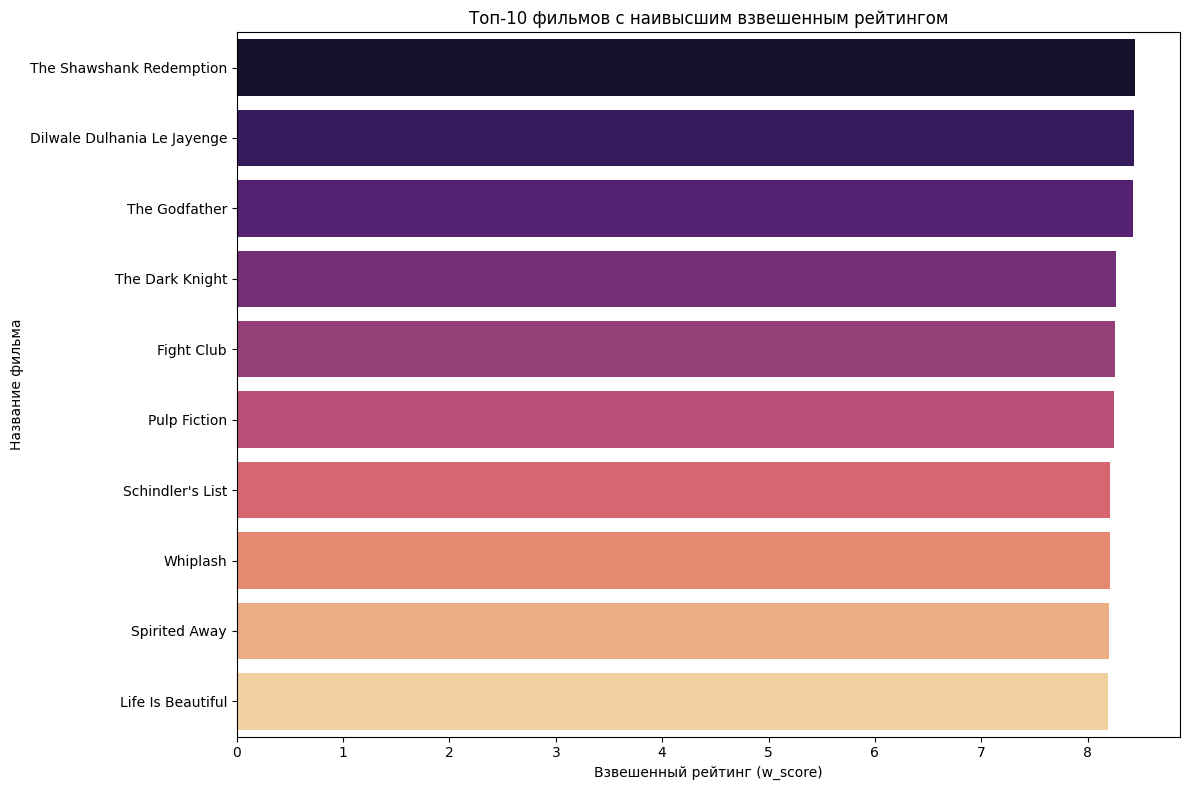

In [108]:
# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(x='w_score', y='title', data=top_10_popular_new, palette='magma')
plt.xlabel('Взвешенный рейтинг (w_score)')
plt.ylabel('Название фильма')
plt.title('Топ-10 фильмов с наивысшим взвешенным рейтингом')
plt.tight_layout()
plt.show()

**Рекомендации по жанру**

In [75]:
def get_top_movies_by_genre(genre_name, n=10):
    """Возвращает топ-N фильмов по указанному жанру"""
    genre_movies = movies[movies['genres'].str.contains(genre_name, case=False, na=False)]
    return genre_movies.sort_values('weighted_rating', ascending=False).head(n)

In [101]:
get_top_movies_by_genre('Drama')

,genres,id,overview,popularity,release_date,runtime,title,vote_average,vote_count,weighted_rating,director,actors,parsed_keywords,metadata_soup
314,Drama|Crime,278,Framed in the 1940s for the double murder of h...,51.645403,1994-09-23,142.0,The Shawshank Redemption,8.5,8358.0,8.445869,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,prison|corruption|police brutality|prison cell...,Framed in the 1940s for the double murder of h...
837,Drama|Crime,238,"Spanning the years 1945 to 1955, a chronicle o...",41.109264,1972-03-14,175.0,The Godfather,8.5,6024.0,8.425439,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,italy|love at first sight|loss of father|patri...,"Spanning the years 1945 to 1955, a chronicle o..."
10357,Comedy|Drama|Romance,19404,"Raj is a rich, carefree, happy-go-lucky second...",34.457024,1995-10-20,190.0,Dilwale Dulhania Le Jayenge,9.1,661.0,8.421453,Aditya Chopra,Shah Rukh Khan|Kajol|Amrish Puri,musical,"Raj is a rich, carefree, happy-go-lucky second..."
12541,Drama|Action|Crime|Thriller,155,Batman raises the stakes in his war on crime. ...,123.167259,2008-07-16,152.0,The Dark Knight,8.3,12269.0,8.265477,Christopher Nolan,Christian Bale|Michael Caine|Heath Ledger,dc comics|crime fighter|secret identity|scarec...,Batman raises the stakes in his war on crime. ...
2858,Drama,550,A ticking-time-bomb insomniac and a slippery s...,63.869599,1999-10-15,139.0,Fight Club,8.3,9678.0,8.256385,David Fincher,Edward Norton|Brad Pitt|Meat Loaf,support group|dual identity|nihilism|rage and ...,A ticking-time-bomb insomniac and a slippery s...
522,Drama|History|War,424,The true story of how businessman Oskar Schind...,41.725123,1993-11-29,195.0,Schindler's List,8.3,4436.0,8.206639,Steven Spielberg,Liam Neeson|Ben Kingsley|Ralph Fiennes,factory|concentration camp|hero|holocaust|worl...,The true story of how businessman Oskar Schind...
23817,Drama,244786,"Under the direction of a ruthless instructor, ...",64.29999,2014-10-10,105.0,Whiplash,8.3,4376.0,8.205404,Damien Chazelle,Miles Teller|J.K. Simmons|Melissa Benoist,jazz|obsession|conservatory|music teacher|new ...,"Under the direction of a ruthless instructor, ..."
2223,Comedy|Drama,637,A touching story of an Italian book seller of ...,39.39497,1997-12-20,116.0,Life Is Beautiful,8.3,3643.0,8.187171,Roberto Benigni,Nicoletta Braschi|Roberto Benigni|Giorgio Cant...,italy|riddle|bookshop|self sacrifice|mass murd...,A touching story of an Italian book seller of ...
1187,Drama|Crime,240,In the continuing saga of the Corleone crime f...,36.629307,1974-12-20,200.0,The Godfather: Part II,8.3,3418.0,8.180076,Francis Ford Coppola,Al Pacino|Robert Duvall|Diane Keaton,italo-american|cuba|vororte|melancholy|praise|...,In the continuing saga of the Corleone crime f...
1161,Drama,510,While serving time for insanity at a state men...,35.529554,1975-11-18,133.0,One Flew Over the Cuckoo's Nest,8.3,3001.0,8.164256,Miloš Forman,Jack Nicholson|Louise Fletcher|Danny DeVito,individual|rebel|self-destruction|wheelchair|l...,While serving time for insanity at a state men...


**Content-Based по названию фильма**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
# Фильтруем фильмы с малым количеством оценок
min_votes = 50
popular_movies = movies[movies['vote_count'] >= min_votes].copy()

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(popular_movies['metadata_soup'])  # только популярные фильмы

# Используем NearestNeighbors для поиска похожих фильмов при помощи косинусового метода
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(tfidf_matrix)

# Создаем словарь для быстрого поиска индекса фильма по названию
indices = pd.Series(popular_movies.index, index=popular_movies['title']).drop_duplicates()

In [ ]:
def recommend(title, n=10):
    if title not in indices:
        return f"Фильм '{title}' не найден в базе данных"
    idx = indices[title]
    indices_knn = model_knn.kneighbors(tfidf_matrix[idx], n_neighbors=n+1)
    similar_indices = indices_knn[0][1:]  # пропускаем сам фильм
    return popular_movies.iloc[similar_indices][['title', 'genres', 'weighted_rating']]

In [111]:
recommend('Toy Story')

,title,genres,weighted_rating
3012,Toy Story 2,Animation|Comedy|Family,7.233950
15444,Toy Story 3,Animation|Family|Comedy,7.534890
24670,Small Fry,Animation|Family,6.119831
1823,Small Soldiers,Comedy|Adventure|Fantasy|Science Fiction|Action,6.063509
25950,Toy Story That Time Forgot,Animation|Family,6.337685
22063,Toy Story of Terror!,Animation|Comedy|Family,6.637225
2154,Toys,Fantasy|Comedy|Science Fiction,5.297036
10349,The 40 Year Old Virgin,Comedy|Romance,6.157300
25948,Partysaurus Rex,Animation|Comedy|Family|Fantasy,6.217067
24668,Hawaiian Vacation,Animation|Family,6.240557


## Коллаборативная фильтрация через pivot_table и корреляцию

 Строим матрицу "пользователь-фильм", вычисляем коррелляцию между фильмами по оценкам пользователей и предлагаем фильмы, которые похожи на выбранный по мнению других зрителей

In [ ]:
# Создаем pivot-таблицу
ratings_pivot = ratings_final.pivot_table(index='userId', columns='title', values='rating')
ratings_pivot.fillna(0, inplace=True)
ratings_pivot.head()

title,$9.99,'Neath the Arizona Skies,"'night, Mother",(500) Days of Summer,...And God Created Woman,...And Justice for All,1-900,10,10 Attitudes,10 Cloverfield Lane,...,eXistenZ,loudQUIETloud: A Film About the Pixies,xXx,xXx: State of the Union,¡Three Amigos!,À Nous la Liberté,Æon Flux,İtirazım Var,Želary,’Round Midnight
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def same_movies(movie):
    # Извлекаем столбец с оценками всех пользователей
    users_vote_film = ratings_pivot[movie]
    # Вычисляем попарные корреляции между целевым фильмом и всеми остальными
    similar_with = ratings_pivot.corrwith(users_vote_film)
    similar_with = pd.DataFrame(similar_with, columns=['correlation'])
    similar_with = similar_with.drop(movie, errors='ignore')
    return similar_with.sort_values('correlation', ascending=False).head(10)

In [ ]:
same_movies('The Dark Knight')

,correlation
title,
Iron Man,0.693863
Batman Begins,0.602425
Inception,0.589515
Avatar,0.518059
WALL·E,0.501274
The Dark Knight Rises,0.499605
Star Trek,0.489044
300,0.488851
The Departed,0.480761


Проверяем схожесть на кинопоиске.

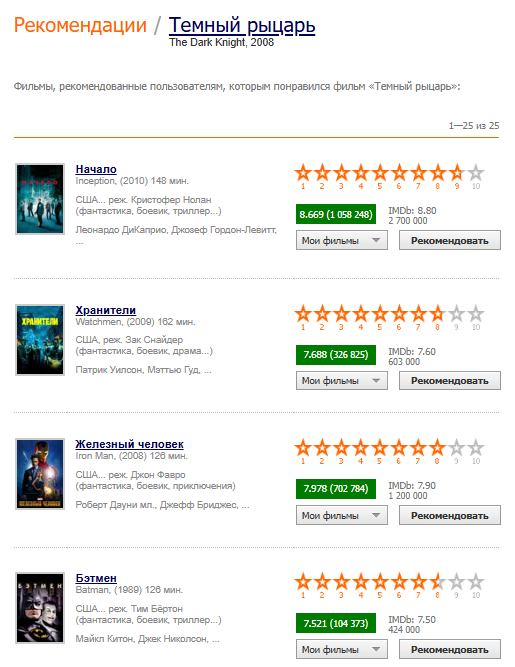

___

## Сохранение моделей и данных

1. Топ-10 популярных фильмов

In [114]:
top_10_popular_new.to_csv('top_10_popular.csv', index=False)

2. Рекомендации по жанру

In [ ]:
movies.to_csv('movies_metadata_clean.csv', index=False)

3. Content-Based модель (TF-IDF + NearestNeighbors)

In [116]:
import pickle
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('knn_content_model.pkl', 'wb') as f:
    pickle.dump(model_knn, f)
popular_movies.to_csv('popular_movies.csv', index=False)

4. Коллаборативная фильтрация (pivot_table + корреляция)

In [117]:
ratings_pivot.to_csv('ratings_pivot.csv')

___

## Вывод

Таким образом, в рамках проекта была реализована рекомендательная система для фильмов, охватывающая четыре ключевых направления:

1. Рекомендации на основе взвешенных рейтингов — реализован расчет рейтинга с учетом среднего значения и количества голосов, что позволяет формировать объективный топ-10 популярных фильмов.
2. Рекомендации по жанру — создана функция, позволяющая пользователю получать лучшие фильмы по выбранному жанру, что удобно для поиска контента по интересам.
3. Контентные рекомендации по названию фильма — реализован алгоритм на основе TF-IDF и поиска ближайших соседей, который находит фильмы, похожие по описанию, ключевым словам, актёрам и режиссёру.
4. Коллаборативная фильтрация — построена pivot-таблица и реализован поиск похожих фильмов на основе корреляции оценок пользователей, что позволяет учитывать вкусы аудитории.

Все необходимые данные и модели сохранены для дальнейшей интеграции в API.

